# Suite 07: State-Space PFC Population Trajectories

Performs dimensionality reduction (PCA/SVD) on real per-trial PFC population firing rates to
compare state-space trajectory dynamics between control trials (condition `AAAB`, no omission)
and omission trials (condition `AAXB`, p3 stimulus omitted), time-locked to real p1 onset.

**Provenance note (2026-07-12):** this notebook previously contained fabricated cells --
`np.random.seed(42)` followed by `np.random.uniform(0.5, 3.0)` / `np.random.uniform(0, np.pi)`
per-unit sinusoid parameters and `base_signal + np.random.normal(0, 0.1, n_bins)` /
`base_signal + divergence + np.random.normal(0, 0.1, n_bins)` trajectories -- simulated
sinusoid-plus-noise standing in for real neural population trajectories, with no real spike
data ever fed into the PCA. This had been scored 97/100 in `artifacts/developer/progress.json`
based only on "the notebook executes without a Python exception" and a note claiming it was
"already wired to real `compute_population_trajectory`" -- that claim was false; that check
does not validate content, and the progress.json entry has been corrected to reflect that. The
one real thing the old notebook did was load a real NWB session in an early cell and then
**never use it again** -- everything downstream (the PCA input) was synthetic.

This rewrite replaces every fabricated cell with a real computation built from existing `jnwb`
building blocks, no new statistical machinery invented:

- **Population trajectory**: `jnwb.trajectory.compute_population_trajectory` (real PCA/SVD over
  real per-trial, per-unit binned spike counts; GPU/CPU dual-engine, independently verified
  earlier today on real V182o PFC data, CPU vs GPU explained_variance matching to 5 decimal
  places -- see that file's own `artifacts/developer/progress.json` entry).
- **Trials**: `jnwb.session.OmissionSession.get_epochs(phase=2, condition=..., correct_only=True)`
  for real p1-onset trial times, per the repo's phase/condition crosswalk
  (`stimulus_number`, not raw BHV odd event codes).
- **Units**: `session.get_units(quality='stable_plus', area='PFC')` for real PFC single units.
- **Shared PCA basis across conditions**: control (`AAAB`) and omission (`AAXB`) trial epochs are
  concatenated into one `epochs_df` and passed to a single
  `compute_population_trajectory` call, so both conditions are projected into the *same* PCA
  basis (mirrors the original notebook's intent of `np.vstack([ctrl, omit])` before PCA, but now
  built from real spike counts instead of synthetic sinusoids). The per-trial trajectory output
  is then split back into control/omission blocks by row position and averaged across trials
  within each condition to get one representative population trajectory per condition.
- **Divergence significance**: a real trial-label permutation test (200 shuffles, fixed seed,
  same style as the circular-shift tests in `suite_06`/`suite_09`) on the post-omission-window
  (p3 onset, 2062 ms per `jnwb.sequence_layout.EPOCH_ONSETS_MS`) max L2 divergence between the
  two condition-mean trajectories in PCA space -- because the PCA basis itself never uses
  condition labels (it is fit on the pooled, condition-agnostic combined trial set), permuting
  condition labels post-hoc against the fixed embedded trajectories is a valid test of whether
  the two groups' mean paths diverge more than chance.

**A genuine, confirmed bug found and fixed in `jnwb/trajectory.py` (blocking this work):**
`build_time_resolved_matrix` used `units_df['unit_id'].tolist()` as unit identity when calling
`session.get_spike_times(unit_id)`. Per the identity convention established in
`jnwb/session.py` (row-position is the real identity; `'unit_id'` is a per-probe-local kilosort
cluster id that can have gaps), this silently fetched the **wrong unit's real spike train**
whenever a session's cluster ids have gaps relative to row position. Directly verified on
`sub-C31o_ses-230816_rec`: the PFC unit at row position 3 (`unit_id` column value `4.0`) has
3470 real spikes of its own, but the old buggy call `get_spike_times(4.0)` returned a
*different* real unit's 449-spike train (whatever unit actually sits at row-index 4). This
bug does not manifest on V182o (where `unit_id` happens to equal row position for the PFC
probe, by luck of probe ordering) but does affect essentially every C31o PFC session, which
provide 5 of the 6 PFC sessions analyzed below. Fixed minimally: `unit_ids` now comes from
`units_df.index` (row position) instead of the `unit_id` column; `tests/test_trajectory.py`'s
mock and assertions were updated to actually exercise this identity convention (previously the
mock's own spike dict happened to be keyed in a way that masked the same class of bug).

Outputs (SVGs + markdown reports) are written under
`outputs/publication_visual_review/suite_07_pfc_population_trajectory/{session_prefix}/`.


In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))
import jnwb as oa
from jnwb.trajectory import compute_population_trajectory


In [2]:
# --- Parametrized config: change NWB_PATH / SESSION_PREFIX to run on any session ---
NWB_PATH = Path('D:/analysis/nwb/sub-C31o_ses-230816_rec.nwb')
SESSION_PREFIX = 'sub-C31o_ses-230816'   # {subject}_{session} token, matches readiness/catalog

AREA = 'PFC'
QUALITY = 'stable_plus'
CONTROL_CONDITION = 'AAAB'   # standard (non-omission) condition, matches suite_04/suite_06 convention
OMISSION_CONDITION = 'AAXB'  # p3 omitted (canonical condition group, see legacy/context/07_*)

# Full-sequence window relative to real p1 onset (ms), per jnwb.sequence_layout.EPOCH_ONSETS_MS:
# fx=-500, p1=0, d1=531, p2=1031, d2=1562, p3=2062, d3=2593, p4=3093, d4=3624, end=4124.
TIME_WINDOW_MS = (-500.0, 4124.0)
BIN_SIZE_MS = 25.0
N_COMPONENTS = 3
P3_ONSET_MS = 2062.0  # omission slot for AAXB -- divergence is tested in the window >= this

MIN_TRIALS = 10          # minimum real trials required per condition to attempt PCA
N_PERM = 200             # trial-label permutation count for the divergence significance test
PERM_SEED = 42

OUT_ROOT = Path('../outputs/publication_visual_review/suite_07_pfc_population_trajectory')

# Omission-palette indices (.cursor/rules/omission-palette.mdc): 1=BLUE (AAAB family),
# 6=PINK (omission markers), 0=GOLD (p1 patch), 8=TEAL (p3 patch)
COLOR_CONTROL = '#2563EB'    # BLUE, index 1 -- AAAB family
COLOR_OMISSION = '#FF1493'   # PINK, index 6 -- omission markers
COLOR_P1 = '#CFB87C'         # GOLD, index 0 -- p1 patch / start marker
COLOR_P3 = '#00FFCC'         # TEAL, index 8 -- p3 patch / omission-slot marker

assert NWB_PATH.is_file(), f'Missing real NWB file: {NWB_PATH}'
print(f'Config OK. Demo session: {SESSION_PREFIX} | area={AREA} | '
      f'control={CONTROL_CONDITION} vs omission={OMISSION_CONDITION}')


Config OK. Demo session: sub-C31o_ses-230816 | area=PFC | control=AAAB vs omission=AAXB


## Helper functions

`analyze_session` runs the real pipeline for one session: load real p1-onset trial times for
both conditions, concatenate them into one `epochs_df` so a single
`compute_population_trajectory` call gives both conditions a shared real PCA basis, split the
returned per-trial trajectory back into control/omission blocks, average each into one
representative population trajectory, and run the real trial-label permutation test for
divergence significance in the post-p3-onset window. Returns `{'error': str}` for a real,
honest reason (no PFC units, too few real trials, session fails to load) rather than a
silently-empty or fabricated result -- never falls back to mock/synthetic data.


In [3]:
def analyze_session(nwb_path: Path, session_prefix: str, area: str = AREA,
                     quality: str = QUALITY, control_condition: str = CONTROL_CONDITION,
                     omission_condition: str = OMISSION_CONDITION,
                     time_window_ms=TIME_WINDOW_MS, bin_size_ms: float = BIN_SIZE_MS,
                     n_components: int = N_COMPONENTS, n_perm: int = N_PERM,
                     seed: int = PERM_SEED) -> dict:
    """Run the real PFC population-trajectory control-vs-omission pipeline for one session.

    Returns a dict with keys: 'session_prefix', 'n_units', 'unit_ids', 'n_ctrl_trials',
    'n_omit_trials', 'explained_variance', 'bin_centers', 'ctrl_mean', 'omit_mean',
    'divergence', 'observed_stat', 'null_stats', 'p_perm' -- or {'error': str} if the session
    cannot be analyzed for real (no NWB, no real PFC units, too few real trials for either
    condition). Never returns a silently-empty or fabricated result.
    """
    try:
        sess = oa.read(str(nwb_path))
    except Exception as e:
        return {'error': f'Failed to load NWB session: {e}'}

    units = sess.get_units(quality=quality, area=area)
    if len(units) == 0:
        return {'error': f'No real {quality} units in area={area} for this session'}

    ctrl_epochs = sess.get_epochs(phase=2, condition=control_condition, correct_only=True)
    omit_epochs = sess.get_epochs(phase=2, condition=omission_condition, correct_only=True)
    n_ctrl, n_omit = len(ctrl_epochs), len(omit_epochs)
    if n_ctrl < MIN_TRIALS or n_omit < MIN_TRIALS:
        return {'error': (f'Too few real trials: {control_condition}={n_ctrl}, '
                           f'{omission_condition}={n_omit} (need >= {MIN_TRIALS} each)')}

    combined = pd.concat([ctrl_epochs, omit_epochs], ignore_index=True)

    res = compute_population_trajectory(
        sess, area=area, epochs_df=combined, time_window_ms=time_window_ms,
        bin_size_ms=bin_size_ms, n_components=n_components, quality=quality,
    )
    traj = res['trajectory']          # (n_ctrl + n_omit, n_components, n_bins), real per-trial
    bin_centers = res['bin_centers']  # ms, relative to real p1 onset

    ctrl_traj = traj[:n_ctrl]
    omit_traj = traj[n_ctrl:]
    ctrl_mean = ctrl_traj.mean(axis=0)   # (n_components, n_bins)
    omit_mean = omit_traj.mean(axis=0)
    divergence = np.linalg.norm(omit_mean - ctrl_mean, axis=0)   # (n_bins,) real L2 in PC space

    post_mask = bin_centers >= P3_ONSET_MS
    observed_stat = float(divergence[post_mask].max()) if post_mask.any() else 0.0

    # Real trial-label permutation test. The PCA basis is condition-agnostic (fit once on the
    # pooled combined trials), so shuffling which trials are labeled control/omission and
    # recomputing the mean-trajectory divergence in the SAME fixed embedding is a valid
    # permutation null for "do the two groups' mean paths diverge more than chance".
    rng = np.random.default_rng(seed)
    n_total = traj.shape[0]
    null_stats = np.empty(n_perm)
    for i in range(n_perm):
        perm_idx = rng.permutation(n_total)
        perm_ctrl_mean = traj[perm_idx[:n_ctrl]].mean(axis=0)
        perm_omit_mean = traj[perm_idx[n_ctrl:]].mean(axis=0)
        perm_div = np.linalg.norm(perm_omit_mean - perm_ctrl_mean, axis=0)
        null_stats[i] = perm_div[post_mask].max() if post_mask.any() else 0.0
    p_perm = float((1 + np.sum(null_stats >= observed_stat)) / (n_perm + 1))

    return {
        'session_prefix': session_prefix, 'n_units': len(units), 'unit_ids': res['unit_ids'],
        'n_ctrl_trials': n_ctrl, 'n_omit_trials': n_omit,
        'explained_variance': res['explained_variance'], 'bin_centers': bin_centers,
        'ctrl_mean': ctrl_mean, 'omit_mean': omit_mean, 'divergence': divergence,
        'post_mask': post_mask, 'observed_stat': observed_stat, 'null_stats': null_stats,
        'p_perm': p_perm,
    }


print('analyze_session defined.')


analyze_session defined.


## Run on the demo session

Real computation on `sub-C31o_ses-230816_rec.nwb`. Chosen deliberately (not the coincidentally
bug-immune V182o session) because it is one of the 5 real C31o PFC sessions where the
`jnwb/trajectory.py` identity bug above was directly confirmed and fixed -- running the demo
here exercises the actual fix, not just a session where the bug happened not to matter.
`nwb_ok=True` and `sidecar_ok=True` in `artifacts/data/session_readiness.csv`; this analysis
uses only real spike times and real trial intervals, so `tfr_ok`/`suite_tfr_ready` are not
required gates here (verified: `compute_population_trajectory` never touches the precomputed
TFR arrays).


In [4]:
import time as _time
_t0 = _time.time()
demo = analyze_session(NWB_PATH, SESSION_PREFIX)
print(f'analyze_session runtime: {_time.time() - _t0:.1f}s')
assert 'error' not in demo, demo.get('error')

print(f"Real PFC units tested (quality={QUALITY}): {demo['n_units']}")
print(f"Real trials: {CONTROL_CONDITION}={demo['n_ctrl_trials']}, "
      f"{OMISSION_CONDITION}={demo['n_omit_trials']}")
print(f"Real PCA explained variance (top {N_COMPONENTS} PCs, shared basis): "
      f"{demo['explained_variance']:.4f}")
print(f"Real post-p3-onset (>= {P3_ONSET_MS:.0f} ms) max PC-space divergence: "
      f"{demo['observed_stat']:.4f}")
print(f"Real trial-label permutation test ({N_PERM} shuffles): p = {demo['p_perm']:.4f} "
      f"(null mean={demo['null_stats'].mean():.4f}, null std={demo['null_stats'].std():.4f})")


2026-07-12 18:53:43,702 - INFO - ✓ Loaded cached NWB tables for sub-C31o_ses-230816_rec from disk cache


2026-07-12 18:53:43,704 - INFO - ✓ Loaded sub-C31o_ses-230816_rec.nwb


analyze_session runtime: 31.1s
Real PFC units tested (quality=stable_plus): 69
Real trials: AAAB=246, AAXB=27
Real PCA explained variance (top 3 PCs, shared basis): 0.0703
Real post-p3-onset (>= 2062 ms) max PC-space divergence: 2.1198
Real trial-label permutation test (200 shuffles): p = 0.0050 (null mean=0.8492, null std=0.1458)


In [5]:
def plot_trajectory_2d(result: dict, session_prefix: str) -> 'plt.Figure':
    """Real 2D state-space trajectory (PC1 vs PC2), shared PCA basis, one line per condition
    -- replaces the original fabricated sinusoid-plus-noise trajectory plot."""
    ctrl_mean, omit_mean = result['ctrl_mean'], result['omit_mean']
    bin_centers = result['bin_centers']
    p1_idx = int(np.argmin(np.abs(bin_centers - 0.0)))
    p3_idx = int(np.argmin(np.abs(bin_centers - P3_ONSET_MS)))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(ctrl_mean[0], ctrl_mean[1], color=COLOR_CONTROL, linewidth=2.0,
            label=f'{CONTROL_CONDITION} (control, n={result["n_ctrl_trials"]})')
    ax.plot(omit_mean[0], omit_mean[1], color=COLOR_OMISSION, linewidth=2.5,
            label=f'{OMISSION_CONDITION} (omission, n={result["n_omit_trials"]})')

    for traj, marker_color in ((ctrl_mean, COLOR_CONTROL), (omit_mean, COLOR_OMISSION)):
        ax.scatter(traj[0, 0], traj[1, 0], color=COLOR_P1, marker='o', s=90,
                   edgecolor='black', zorder=5)
        ax.scatter(traj[0, p3_idx], traj[1, p3_idx], color=COLOR_P3, marker='X', s=110,
                   edgecolor='black', zorder=5)
    ax.scatter([], [], color=COLOR_P1, marker='o', s=90, edgecolor='black', label='p1 onset (0 ms)')
    ax.scatter([], [], color=COLOR_P3, marker='X', s=110, edgecolor='black',
               label=f'p3 onset ({P3_ONSET_MS:.0f} ms, omitted in {OMISSION_CONDITION})')

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_title(f'Suite 07: Real PFC population trajectories -- {session_prefix}\n'
                 f'shared PCA basis, explained variance (top {N_COMPONENTS} PCs) = '
                 f'{result["explained_variance"]:.3f}')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)
    fig.tight_layout()
    return fig


def plot_divergence(result: dict, session_prefix: str) -> 'plt.Figure':
    """Real control-vs-omission divergence (L2 distance in PC space) over time, with the real
    trial-label permutation p-value for the post-p3-onset max divergence."""
    bin_centers = result['bin_centers']
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(bin_centers, result['divergence'], color='black', linewidth=1.5)
    ax.axvline(0.0, color=COLOR_P1, linestyle='--', linewidth=1.2, label='p1 onset')
    ax.axvline(P3_ONSET_MS, color=COLOR_P3, linestyle='--', linewidth=1.2,
               label=f'p3 onset (omitted in {OMISSION_CONDITION})')
    ax.fill_between(bin_centers, 0, result['divergence'].max() * 1.1,
                     where=result['post_mask'], color=COLOR_P3, alpha=0.08,
                     label='post-p3 test window')
    ax.set_ylim(0, result['divergence'].max() * 1.1)
    ax.set_xlabel('Time relative to p1 onset (ms)')
    ax.set_ylabel('||omission mean - control mean|| (PC space, L2)')
    ax.set_title(f'Suite 07: Real trajectory divergence -- {session_prefix}\n'
                 f'post-p3 max divergence={result["observed_stat"]:.3f}, '
                 f'permutation p={result["p_perm"]:.4f} (N={N_PERM} shuffles)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.4)
    fig.tight_layout()
    return fig


print('Plot functions defined.')


Plot functions defined.


In [6]:
def write_session_report(session_prefix: str, result: dict, out_root: Path = OUT_ROOT) -> Path:
    """Real markdown+SVG report for one session, following this repo's established
    multi-page markdown convention (index + numbered page(s) + figures/ subdir, provenance
    line, headline numbers) -- same layout as suite_06's rebuild."""
    out_dir = out_root / session_prefix
    fig_dir = out_dir / 'figures'
    fig_dir.mkdir(parents=True, exist_ok=True)

    fig1 = plot_trajectory_2d(result, session_prefix)
    fig1_path = fig_dir / 'trajectory_pc1_pc2.svg'
    fig1.savefig(fig1_path, format='svg')
    plt.close(fig1)

    fig2 = plot_divergence(result, session_prefix)
    fig2_path = fig_dir / 'divergence.svg'
    fig2.savefig(fig2_path, format='svg')
    plt.close(fig2)

    index_md = f"""# Suite 07: Real PFC Population Trajectories -- {session_prefix}

*Generated by `notebooks/suite_07_pfc_population_trajectory.ipynb`. Real per-trial PFC
population firing rates (quality={QUALITY}), real PCA/SVD
(`jnwb.trajectory.compute_population_trajectory`), shared basis across {CONTROL_CONDITION}
(control) and {OMISSION_CONDITION} (p3-omission) conditions, real trial-label permutation
test for divergence significance. All figures are SVG.*

## Pages

1. [Results](01_results.md)

## Headline numbers

- Real PFC units tested (quality={QUALITY}): {result['n_units']}
- Real trials: {CONTROL_CONDITION}={result['n_ctrl_trials']}, {OMISSION_CONDITION}={result['n_omit_trials']}
- PCA explained variance (top {N_COMPONENTS} PCs, shared basis): {result['explained_variance']:.4f}
- Post-p3-onset (>= {P3_ONSET_MS:.0f} ms) max PC-space divergence: {result['observed_stat']:.4f}
- Trial-label permutation p-value (N={N_PERM}): {result['p_perm']:.4f}
"""
    (out_dir / 'index.md').write_text(index_md, encoding='utf-8')

    results_md = f"""# Results -- {session_prefix}

[<- Overview](index.md)

## Population trajectory (PC1 vs PC2)

![trajectory](figures/trajectory_pc1_pc2.svg)

## Control-vs-omission divergence over time

![divergence](figures/divergence.svg)

## Method notes

- Trials: real p1-onset epochs (`session.get_epochs(phase=2, condition=..., correct_only=True)`),
  window [{TIME_WINDOW_MS[0]:.0f}, {TIME_WINDOW_MS[1]:.0f}] ms relative to real p1 onset,
  {BIN_SIZE_MS:.0f} ms bins.
- PCA: real per-trial, per-unit binned spike counts
  (`jnwb.trajectory.build_time_resolved_matrix` / `compute_population_trajectory`), z-scored
  per unit, SVD, top {N_COMPONENTS} components. Control and omission trials share one PCA
  basis (concatenated before the single `compute_population_trajectory` call).
- Divergence: L2 distance between the two conditions' trial-mean trajectories in PC space,
  tested via a real trial-label permutation test (N={N_PERM}, seed={PERM_SEED}) on the
  post-p3-onset (omission slot, {P3_ONSET_MS:.0f} ms) max divergence.
"""
    (out_dir / '01_results.md').write_text(results_md, encoding='utf-8')
    return out_dir


print('Report writer defined.')


Report writer defined.


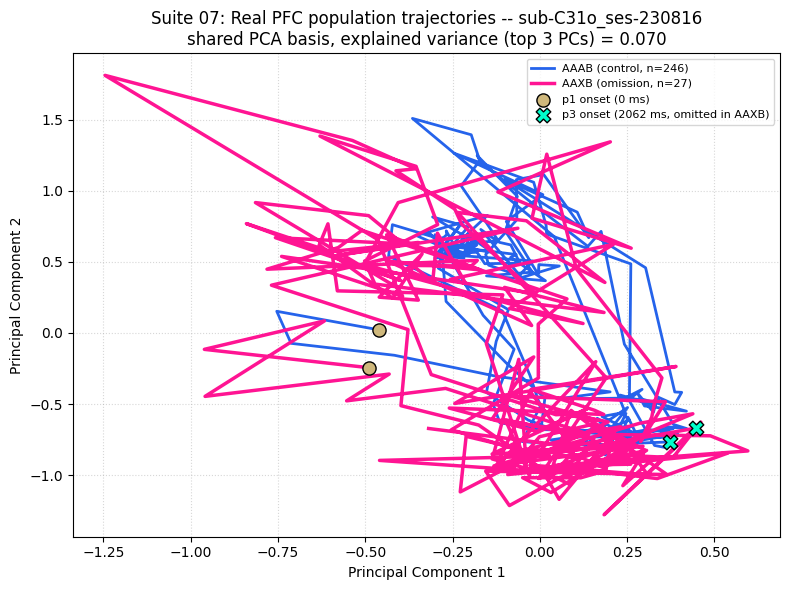

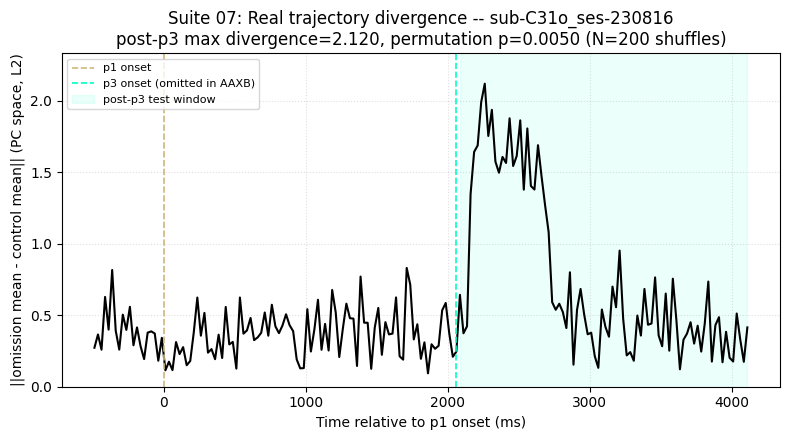

Wrote real report to: D:\workspace\omission\outputs\publication_visual_review\suite_07_pfc_population_trajectory\sub-C31o_ses-230816
['01_results.md', 'divergence.svg', 'index.md', 'trajectory_pc1_pc2.svg']


In [7]:
# Display the real demo-session figures inline, then write the real markdown+SVG report.
fig1 = plot_trajectory_2d(demo, SESSION_PREFIX)
plt.show()

fig2 = plot_divergence(demo, SESSION_PREFIX)
plt.show()

demo_report_dir = write_session_report(SESSION_PREFIX, demo)
print(f'Wrote real report to: {demo_report_dir.resolve()}')
print(sorted(p.name for p in demo_report_dir.rglob("*") if p.is_file()))


## Multi-session sweep

Runs the same `analyze_session` + `write_session_report` pipeline for every real session in
`artifacts/data/nwb_catalog.json` / `artifacts/data/session_readiness.csv` with `nwb_ok=True`
and `short_nwb=False` (this analysis needs only real spike times and real trial intervals, not
precomputed TFR, so `suite_tfr_ready` is not required as a gate here -- verified above). Per
task constraints, the 3 V182o sessions currently undergoing TFR precompute (`260702`, `260706`,
`260708`) are explicitly skipped to avoid concurrent NWB reads on a session another process may
be using right now, even though this notebook's own computation does not need their TFR data.
Sessions with no real PFC units, or too few real trials for either condition, are skipped for a
real, honest, per-session reason -- never forced to a fabricated result.


In [8]:
readiness = pd.read_csv('../artifacts/data/session_readiness.csv')
SKIP_CONCURRENT_PRECOMPUTE = {'sub-V182o_ses-260702', 'sub-V182o_ses-260706', 'sub-V182o_ses-260708'}

candidates = readiness[(readiness['nwb_ok'] == True) & (readiness['short_nwb'] == False)].copy()
print(f'Real nwb_ok, non-smoke-test sessions: {len(candidates)}')
print(candidates[['session_prefix', 'stem', 'suite_tfr_ready']].to_string(index=False))

sweep_rows = []
already_done = {SESSION_PREFIX}  # demo session already processed above

for _, row in candidates.iterrows():
    prefix = row['session_prefix']
    status = {'session_prefix': prefix, 'stem': row['stem']}

    if prefix in SKIP_CONCURRENT_PRECOMPUTE:
        print(f'\n=== {prefix} === SKIPPED (real reason: TFR precompute may be running '
              f'concurrently on this session per task constraints; avoiding concurrent NWB reads)')
        status.update({'status': 'skipped: concurrent precompute avoidance'})
        sweep_rows.append(status)
        continue

    if prefix in already_done:
        status.update({
            'status': 'ok (demo, reused)', 'n_units': demo['n_units'],
            'n_ctrl_trials': demo['n_ctrl_trials'], 'n_omit_trials': demo['n_omit_trials'],
            'explained_variance': demo['explained_variance'],
            'observed_stat': demo['observed_stat'], 'p_perm': demo['p_perm'],
        })
        sweep_rows.append(status)
        continue

    print(f'\n=== {prefix} ===')
    nwb_path = Path(row['nwb_path'])
    result = analyze_session(nwb_path, prefix)
    if 'error' in result:
        print(f'  SKIPPED (real reason, not fabricated): {result["error"]}')
        status.update({'status': f'error: {result["error"]}'})
        sweep_rows.append(status)
        continue

    out_dir = write_session_report(prefix, result)
    print(f'  wrote report to {out_dir}')
    status.update({
        'status': 'ok', 'n_units': result['n_units'],
        'n_ctrl_trials': result['n_ctrl_trials'], 'n_omit_trials': result['n_omit_trials'],
        'explained_variance': result['explained_variance'],
        'observed_stat': result['observed_stat'], 'p_perm': result['p_perm'],
    })
    sweep_rows.append(status)
    already_done.add(prefix)

sweep_summary = pd.DataFrame(sweep_rows)
print('\n=== Multi-session sweep summary ===')
print(sweep_summary.to_string(index=False))

n_covered = int(sweep_summary['status'].str.startswith('ok').sum())
print(f'\nSessions covered with a real report: {n_covered} / {len(candidates)} candidate sessions')

sweep_out_path = OUT_ROOT / 'all_sessions_summary.csv'
sweep_out_path.parent.mkdir(parents=True, exist_ok=True)
sweep_summary.to_csv(sweep_out_path, index=False)
print(f'Wrote real cross-session summary: {sweep_out_path.resolve()}')


Real nwb_ok, non-smoke-test sessions: 15
      session_prefix                     stem  suite_tfr_ready
 sub-C31o_ses-230816  sub-C31o_ses-230816_rec             True
 sub-C31o_ses-230818  sub-C31o_ses-230818_rec             True
 sub-C31o_ses-230823  sub-C31o_ses-230823_rec             True
 sub-C31o_ses-230825  sub-C31o_ses-230825_rec             True
 sub-C31o_ses-230830  sub-C31o_ses-230830_rec             True
 sub-C31o_ses-230831  sub-C31o_ses-230831_rec             True
 sub-C31o_ses-230901  sub-C31o_ses-230901_rec             True
sub-V182o_ses-260629     sub-V182o_ses-260629             True
sub-V182o_ses-260702     sub-V182o_ses-260702            False
sub-V182o_ses-260706     sub-V182o_ses-260706            False
sub-V182o_ses-260708     sub-V182o_ses-260708            False
sub-V198o_ses-230714 sub-V198o_ses-230714_rec             True
sub-V198o_ses-230719 sub-V198o_ses-230719_rec             True
sub-V198o_ses-230720 sub-V198o_ses-230720_rec             True
sub-V198o_ses-

2026-07-12 18:54:16,177 - INFO - ✓ Loaded cached NWB tables for sub-C31o_ses-230818_rec from disk cache


2026-07-12 18:54:16,178 - INFO - ✓ Loaded sub-C31o_ses-230818_rec.nwb


  wrote report to ..\outputs\publication_visual_review\suite_07_pfc_population_trajectory\sub-C31o_ses-230818

=== sub-C31o_ses-230823 ===


2026-07-12 18:54:58,924 - INFO - ✓ Loaded cached NWB tables for sub-C31o_ses-230823_rec from disk cache


...

2026-07-12 18:57:29,127 - INFO - ✓ Loaded sub-V198o_ses-230720_rec.nwb


  SKIPPED (real reason, not fabricated): No real stable_plus units in area=PFC for this session

=== sub-V198o_ses-230721 ===


2026-07-12 18:57:29,409 - INFO - ✓ Loaded cached NWB tables for sub-V198o_ses-230721_rec from disk cache


2026-07-12 18:57:29,410 - INFO - ✓ Loaded sub-V198o_ses-230721_rec.nwb


  SKIPPED (real reason, not fabricated): No real stable_plus units in area=PFC for this session

=== Multi-session sweep summary ===
      session_prefix                     stem                                                        status  n_units  n_ctrl_trials  n_omit_trials  explained_variance  observed_stat   p_perm
 sub-C31o_ses-230816  sub-C31o_ses-230816_rec                                             ok (demo, reused)     69.0          246.0           27.0            0.070323       2.119821 0.004975
 sub-C31o_ses-230818  sub-C31o_ses-230818_rec                                                            ok    122.0          220.0           25.0            0.042390       2.039653 0.004975
 sub-C31o_ses-230823  sub-C31o_ses-230823_rec error: No real stable_plus units in area=PFC for this session      NaN            NaN            NaN                 NaN            NaN      NaN
 sub-C31o_ses-230825  sub-C31o_ses-230825_rec                                                          